# S0: Temporal Persistence Profiling

**Goal**: Measure oracle δ = ‖h(t) - h(t-1)‖ / ‖h(t-1)‖ (ground truth channel variation)

**Key questions**:
1. How much does the channel change between consecutive slots? (go/no-go)
2. Static δ ≈ 0? (simulator noise floor sanity check)  
3. NMSE if we reuse previous estimate?

Run cells sequentially. Data loads once and stays in memory.

In [1]:
import sys; sys.path.insert(0, "../../..")  # project root
from src.experiments.S0_persistence.core import load_data, run_all_bs, check_go_nogo, save_results, load_results
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

PRESET = "munich_elaa_m_1k_15g"  # has h5 data ready
MAX_SNAPSHOTS = 400              # snapshots per UE (dt=0.25ms → 1.0s window)

In [2]:
# Load data (slow — stays in memory for re-analysis)
# Or load cached results if available
GPU = "0,1,2,3,4,5,6"  # multi-GPU for CIR→CFR, results on CPU
UE_PER_SPEED = 2        # 2 UEs per speed category (static/ped/veh) = 6 total

result = load_results(PRESET)
if result is None:
    print("No cached results, computing...")
    data = load_data(PRESET, max_snapshots=MAX_SNAPSHOTS)
    result = run_all_bs(data, PRESET, gpu=GPU, max_snapshots=MAX_SNAPSHOTS, ue_per_speed=UE_PER_SPEED)
    save_results(result)
    print("Saved results. Data stays in memory.")
else:
    print(f"Loaded cached results: {result['summary']['n_ues']} UEs")

per_ue = result["per_ue"]
summary = result["summary"]
print(f"\nSummary: median δ={summary['median_delta']:.4f}, "
      f"static δ={summary['static_median_delta']:.4f}, "
      f"NMSE(reuse)={summary['median_nmse_reuse_db']:.1f}dB")
print(f"\nPer UE:")
for u in per_ue:
    label = 'static' if u['speed']<0.1 else ('ped' if u['speed']<5 else 'veh')
    d_ls = u.get('median_delta_ls', '?')
    d_ls_str = f"{d_ls:.4f}" if isinstance(d_ls, float) else d_ls
    print(f"  UE {u['uid']} ({label}): δ_oracle={u['median_delta']:.4f}, δ_LS={d_ls_str}, NMSE={u['nmse_reuse_db']:.1f}dB")

No cached results, computing...
Loaded munich_elaa_m_1k_15g: 400 snapshots, 9 UEs, dt=0.00025s
  BS 0: 0 UEs, skipping
  BS 2: 0 UEs, skipping
  BS 3: 0 UEs, skipping


CIR→CFR (7 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (7 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (7 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (7 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

...

CIR→CFR (7 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (7 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (7 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

CIR→CFR (7 GPU):   0%|          | 0/1 [00:00<?, ?chunk/s]

  BS 1: 6 UEs, median δ=0.0306, static δ=0.0048
Saved: assets/results/S0_persistence/persistence_munich_elaa_m_1k_15g.json
Saved results. Data stays in memory.

Summary: median δ=0.0306, static δ=0.0048, NMSE(reuse)=-21.5dB

Per UE:
  UE 0 (static): δ_oracle=0.0083, δ_LS=0.1410, NMSE=-22.3dB
  UE 1 (static): δ_oracle=0.0014, δ_LS=0.1407, NMSE=-23.1dB
  UE 3 (ped): δ_oracle=0.0000, δ_LS=0.1407, NMSE=-23.0dB
  UE 4 (ped): δ_oracle=0.0530, δ_LS=0.1502, NMSE=-20.6dB
  UE 6 (veh): δ_oracle=0.2606, δ_LS=0.2950, NMSE=-10.5dB
  UE 8 (veh): δ_oracle=0.3178, δ_LS=0.3461, NMSE=-9.7dB


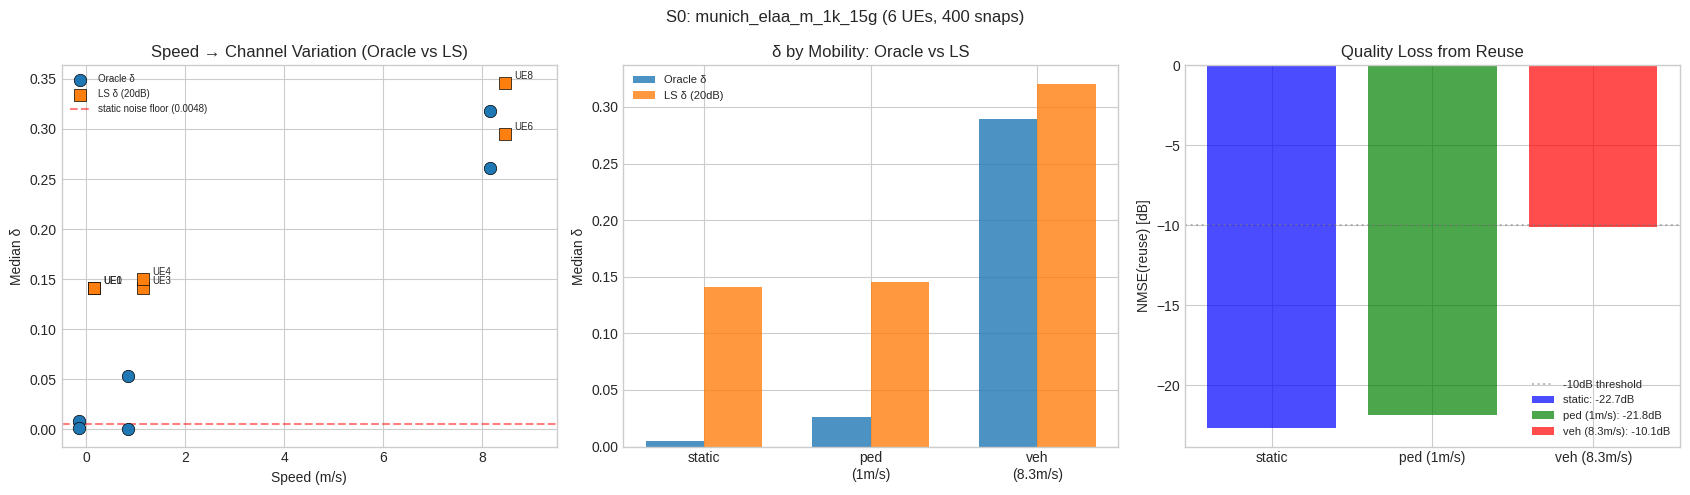

In [3]:
# Plot: Per-UE results — Oracle δ vs LS δ
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

speeds = np.array([u["speed"] for u in per_ue])
deltas_oracle = np.array([u["median_delta"] for u in per_ue])
deltas_ls = np.array([u.get("median_delta_ls", u["median_delta"]) for u in per_ue])
nmses = np.array([u["nmse_reuse_db"] for u in per_ue])

# 1a: Speed vs δ — Oracle AND LS side by side
ax = axes[0]
for i, u in enumerate(per_ue):
    spd = u["speed"]
    d_o = u["median_delta"]
    d_l = u.get("median_delta_ls", d_o)
    ax.scatter(spd - 0.15, d_o, c="tab:blue", s=80, edgecolors="k", linewidths=0.5, zorder=5,
               marker="o", label="Oracle δ" if i == 0 else "")
    ax.scatter(spd + 0.15, d_l, c="tab:orange", s=80, edgecolors="k", linewidths=0.5, zorder=5,
               marker="s", label="LS δ (20dB)" if i == 0 else "")
    ax.annotate(f"UE{u['uid']}", (spd + 0.2, max(d_o, d_l)),
                textcoords="offset points", xytext=(5, 3), fontsize=7)
ax.axhline(summary["static_median_delta"], color="red", ls="--", alpha=0.5,
           label=f"static noise floor ({summary['static_median_delta']:.4f})")
ax.set_xlabel("Speed (m/s)")
ax.set_ylabel("Median δ")
ax.set_title("Speed → Channel Variation (Oracle vs LS)")
ax.set_xlim(-0.5, 9.5)
ax.legend(fontsize=7, loc="upper left")

# 1b: Grouped bar — Oracle vs LS by speed category
ax = axes[1]
cats = {"static": 0.0, "ped\n(1m/s)": 1.0, "veh\n(8.3m/s)": 8.3}
x_pos = np.arange(len(cats))
w = 0.35
for j, (deltas_arr, label, color) in enumerate([
    (deltas_oracle, "Oracle δ", "tab:blue"),
    (deltas_ls, "LS δ (20dB)", "tab:orange"),
]):
    vals = []
    for i, (cat_label, spd) in enumerate(cats.items()):
        mask = np.abs(speeds - spd) < 0.1
        vals.append(np.median(deltas_arr[mask]) if mask.any() else 0)
    ax.bar(x_pos + (j - 0.5) * w, vals, w, color=color, alpha=0.8, label=label)
ax.set_xticks(x_pos)
ax.set_xticklabels(cats.keys())
ax.set_ylabel("Median δ")
ax.set_title("δ by Mobility: Oracle vs LS")
ax.legend(fontsize=8)

# 1c: NMSE(reuse) by speed
ax = axes[2]
bar_colors = ["blue", "green", "red"]
for i, (label, spd) in enumerate({"static": 0.0, "ped (1m/s)": 1.0, "veh (8.3m/s)": 8.3}.items()):
    mask = np.abs(speeds - spd) < 0.1
    valid = nmses[mask]
    valid = valid[~np.isnan(valid)]
    if len(valid) > 0:
        med = np.median(valid)
        ax.bar(i, med, color=bar_colors[i], alpha=0.7, label=f"{label}: {med:.1f}dB")
ax.axhline(-10, color="gray", ls=":", alpha=0.5, label="-10dB threshold")
ax.set_xticks(range(3))
ax.set_xticklabels(["static", "ped (1m/s)", "veh (8.3m/s)"])
ax.set_ylabel("NMSE(reuse) [dB]")
ax.set_title("Quality Loss from Reuse")
ax.legend(fontsize=8)

fig.suptitle(f"S0: {PRESET} ({summary['n_ues']} UEs, {MAX_SNAPSHOTS} snaps)", fontsize=12)
plt.tight_layout()
plt.show()

## GO / NO-GO

In [4]:
check_go_nogo([result])

  ✓ GO: munich_elaa_m_1k_15g median δ = 0.031 ≤ 0.5


True

---
# Unified Pipeline: S0 + S2 + S4 + S5

Run all experiments in a single UE pass (1 CIR→CFR per UE).
Results cached to JSON for instant reload.

In [ ]:
import json
from pathlib import Path
from src.experiments.pipeline import run_all_experiments

CACHE_PATH = Path(f"assets/results/pipeline_{PRESET}.json")

if CACHE_PATH.exists():
    with open(CACHE_PATH) as f:
        R = json.load(f)
    print(f"Loaded cached pipeline results ({len(R['s0']['per_ue'])} UEs)")
else:
    print("Running unified pipeline (S0+S2+S4+S5)...")
    R = run_all_experiments(PRESET, max_snapshots=MAX_SNAPSHOTS, ue_per_speed=UE_PER_SPEED)
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(CACHE_PATH, "w") as f:
        json.dump(R, f, indent=2)
    print(f"Saved to {CACHE_PATH}")

## S2: Threshold Sweep → Pareto Front
τ sweep: skip rate vs NMSE tradeoff.

In [ ]:
sweep = R["s2"]["sweep"]
taus = [s["tau"] for s in sweep]
nmses = [s["avg_nmse_db"] for s in sweep]
srs = [s["skip_rate"] for s in sweep]
crs = [s["computation_ratio"] for s in sweep]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2a: Skip Rate vs NMSE
ax = axes[0]
ax.plot(srs, nmses, "b-o", ms=4)
ax.set_xlabel("Skip Rate")
ax.set_ylabel("NMSE (dB)")
ax.set_title("S2: Skip Rate vs NMSE")
ax.axhline(-10, color="gray", ls=":", label="-10dB threshold")
ax.legend()
ax.invert_xaxis()

# 2b: Computation Ratio vs NMSE
ax = axes[1]
ax.plot(crs, nmses, "r-s", ms=4)
ax.set_xlabel("Computation Ratio (lower = better)")
ax.set_ylabel("NMSE (dB)")
ax.set_title("S2: Pareto Front (CR vs NMSE)")
ax.axhline(-10, color="gray", ls=":", label="-10dB threshold")
ax.legend()

fig.suptitle(f"S2: {PRESET}", fontsize=12)
plt.tight_layout()
plt.show()

# Find sweet spot: best CR where NMSE ≤ -10dB
sweet = [s for s in sweep if s["avg_nmse_db"] <= -10]
if sweet:
    best = min(sweet, key=lambda s: s["computation_ratio"])
    print(f"\nSweet spot: τ={best['tau']:.2f}, SR={best['skip_rate']:.0%}, "
          f"CR={best['computation_ratio']:.3f}, NMSE={best['avg_nmse_db']:.1f}dB")

## S4: Delta Update Ablation
Compare T1 modes: pure skip vs EMA vs LS-delta at τ=0.2.

In [ ]:
s4 = R["s4"]
modes = list(s4.keys())
speed_cats = ["static", "ped", "veh"]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(speed_cats))
w = 0.8 / len(modes)

for j, mode in enumerate(modes):
    vals = [s4[mode].get(sc, {}).get("nmse_db", 0) for sc in speed_cats]
    ax.bar(x + j * w, vals, w, label=mode, alpha=0.8)

ax.set_xticks(x + w * len(modes) / 2)
ax.set_xticklabels(speed_cats)
ax.set_ylabel("NMSE (dB)")
ax.set_title("S4: Delta Update Ablation (τ=0.2)")
ax.legend(fontsize=7, ncol=3)
ax.axhline(-10, color="gray", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

# Best mode
print("Best NMSE per speed category:")
for sc in speed_cats:
    best_mode = min(modes, key=lambda m: s4[m].get(sc, {}).get("nmse_db", 0))
    val = s4[best_mode].get(sc, {}).get("nmse_db", float("nan"))
    print(f"  {sc}: {best_mode} → {val:.1f}dB")

## S5: Beamforming Rate Impact
Rate loss from stale channel estimates across SNR × τ.

In [ ]:
s5 = R["s5"]
snr_keys = sorted(s5.keys())
tau_keys = sorted(s5[snr_keys[0]].keys())

# Heatmap: RPR
rpr_mat = np.zeros((len(snr_keys), len(tau_keys)))
rl5_mat = np.zeros_like(rpr_mat)
for i, sk in enumerate(snr_keys):
    for j, tk in enumerate(tau_keys):
        rpr_mat[i, j] = s5[sk][tk]["avg_rpr"]
        rl5_mat[i, j] = s5[sk][tk]["frac_above_5pct"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
im = ax.imshow(rpr_mat, aspect="auto", cmap="RdYlGn", vmin=0.8, vmax=1.0)
ax.set_xticks(range(len(tau_keys)))
ax.set_xticklabels([tk.replace("tau", "τ=") for tk in tau_keys], fontsize=8)
ax.set_yticks(range(len(snr_keys)))
ax.set_yticklabels([sk.replace("snr", "") + "dB" for sk in snr_keys])
ax.set_xlabel("Threshold τ")
ax.set_ylabel("SNR")
ax.set_title("S5: Rate Preservation Ratio (RPR)")
for i in range(len(snr_keys)):
    for j in range(len(tau_keys)):
        ax.text(j, i, f"{rpr_mat[i,j]:.3f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax)

ax = axes[1]
im2 = ax.imshow(rl5_mat, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=0.5)
ax.set_xticks(range(len(tau_keys)))
ax.set_xticklabels([tk.replace("tau", "τ=") for tk in tau_keys], fontsize=8)
ax.set_yticks(range(len(snr_keys)))
ax.set_yticklabels([sk.replace("snr", "") + "dB" for sk in snr_keys])
ax.set_xlabel("Threshold τ")
ax.set_ylabel("SNR")
ax.set_title("S5: P(rate_loss > 5%)")
for i in range(len(snr_keys)):
    for j in range(len(tau_keys)):
        ax.text(j, i, f"{rl5_mat[i,j]:.0%}", ha="center", va="center", fontsize=8)
plt.colorbar(im2, ax=ax)

fig.suptitle(f"S5: {PRESET}", fontsize=12)
plt.tight_layout()
plt.show()

# Sweet spots
print("\nSweet spots (RPR > 0.95 AND P(rl>5%) < 10%):")
for i, sk in enumerate(snr_keys):
    for j, tk in enumerate(tau_keys):
        if rpr_mat[i,j] > 0.95 and rl5_mat[i,j] < 0.10:
            print(f"  ✓ {sk} {tk}: RPR={rpr_mat[i,j]:.3f}, P(rl>5%)={rl5_mat[i,j]:.0%}")